In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from src.utils.molecule_utils import (
    build_molecule_geometries,
    build_pyscf_molecule,
    compute_integrals,
    compute_cc,
    compute_ccsd
)
from src.simulations.benchmarks.hf import hf

In [4]:
hf_mol_perturbed = hf(perturb=True, bond_noise=0.1)
print(f"HF molecule (perturbed): {hf_mol_perturbed}")

HF molecule (perturbed): [('F', [0.0, 0.0, 0.0]), ('H', [0.8294890740601625, 0.0, 0.0])]


In [5]:
hf_assembled = build_molecule_geometries(molecule_fun=hf, molecule_kwargs={"perturb": True})
print(f"Assembled HF molecule: {hf_assembled}")

Assembled HF molecule: {'atoms': array(['F', 'H'], dtype=object), 'positions': array([[0.        , 0.        , 0.        ],
       [0.84567076, 0.        , 0.        ]], dtype=float32)}


In [6]:
hf_pyscf_mole = build_pyscf_molecule(**hf_assembled)
hf_pyscf_mole

In [7]:
integrals = compute_integrals(hf_pyscf_mole)
for k, v in integrals.items():
    print(f"{k}: {v.shape}")

kinetic_energy: (44, 44)
nuc_attraction: (44, 44)
overlaps: (44, 44)
eri: (44, 44, 44, 44)


In [8]:
cc = compute_cc(hf_pyscf_mole, flatten=False)
for k, v in cc.items():
    if k != "total_energy":
        print(f"{k}: {v.shape}")
    else:
        print(f"{k}: {v}")

t1: (5, 39)
t2: (5, 5, 39, 39)
ccsd_energy: ()


In [9]:
t2 = np.transpose(cc["t2"], (0, 2, 1, 3))
a, i, b, j = t2.shape
t2_flatten = np.reshape(t2, newshape=(a * i, b * j))

<Axes: >

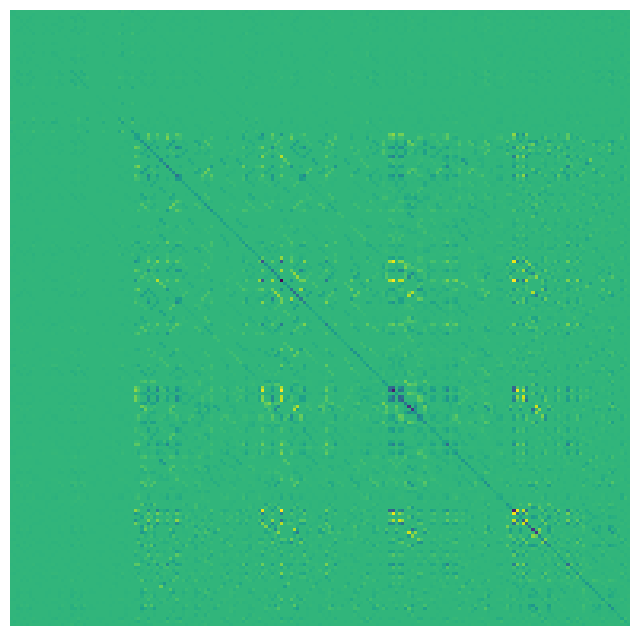

In [10]:
f, ax = plt.subplots(1, 1, figsize=(8, 8))

sns.heatmap(t2_flatten, cmap="viridis", cbar=False, ax=ax, xticklabels=False, yticklabels=False)

<Axes: >

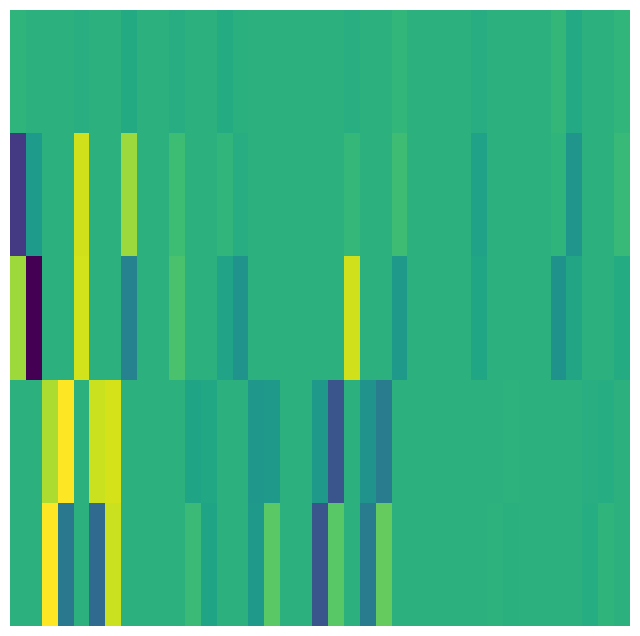

In [11]:
f, ax = plt.subplots(1, 1, figsize=(8, 8))

sns.heatmap(cc["t1"], cmap="viridis", cbar=False, ax=ax, xticklabels=False, yticklabels=False)

In [12]:
sim = compute_ccsd(molecule_fun=hf, molecule_kwargs={"perturb": True})

In [13]:
for k, v in sim.items():
    print(f"{k}: {v.shape}")

atoms: (2,)
positions: (2, 3)
kinetic_energy: (44, 44)
nuc_attraction: (44, 44)
overlaps: (44, 44)
eri: (44, 44, 44, 44)
t1: (5, 39)
t2: (5, 5, 39, 39)
ccsd_energy: ()


In [14]:
from src.simulations.molecules import MoleculeSimulator

In [15]:
hf_simulator = MoleculeSimulator(
    molecule_fun=hf,
    molecule_kwargs={"perturb": True}
)

In [18]:
samples = hf_simulator.sample(num_samples=4, include_kwargs={"include_all": True})

Generating samples: 100%|██████████| 4/4 [00:40<00:00, 10.16s/it]
